In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
import torch

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.backend.backend()}") # 이 부분이 'torch'로 나와야 합니다.
print(f"PyTorch version: {torch.__version__}")

Keras version: 3.11.2
Keras backend: torch
PyTorch version: 2.7.1+cu118


In [2]:
# 작업 준비
import numpy as np
import pandas as pd
# 데이터 분할
from sklearn.model_selection import train_test_split
# 모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, SimpleRNN, \
    LSTM, GRU, BatchNormalization, Flatten
from keras.optimizers import Adam, RMSprop, SGD
from keras.losses import categorical_crossentropy, binary_crossentropy, \
    sparse_categorical_crossentropy, mean_squared_error
# 모델 학습
from keras.callbacks import EarlyStopping, ModelCheckpoint
# 모델 로드
from keras.models import load_model
# 성능 검토
# from keras.metrics import R2Score, RootMeanSquaredError # 다소 어려운 구간임
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error
from keras.utils import to_categorical
import matplotlib.pyplot as plt

from keras.applications import VGG16

In [3]:
import os, shutil, pathlib, gdown
old_dir = pathlib.Path('./dogs-vs-cats/train')
old_dir # 기준 경로를 만들어야함
new_dir = pathlib.Path('./dogs-vs-cats_data')

In [ ]:
def make_subset(sub_n, s_idx, e_idx):
    for i in ['cat', 'dog']:
        dir=new_dir/sub_n/i
        os.makedirs(dir, exist_ok=True)
        f_ns = [f'{i}.{n}.jpg' for n in range(s_idx, e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n,dst=dir/f_n)

In [ ]:
make_subset('tr_data',0,1000) # 새폴더에 이미지 분류 및 복사
make_subset('tt_data',1000,2000)

In [14]:
from keras.utils import image_dataset_from_directory # 자동으로 데이터셋을 리사이징 작업하고 데이터셋화를 함 -> 조건은 폴더가 정리되어 있어야 함
tr_ds = image_dataset_from_directory(new_dir/'tr_data',batch_size=32, image_size=(180,180))
tt_ds = image_dataset_from_directory(new_dir/'tt_data',batch_size=32, image_size=(180,180))

Found 2000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


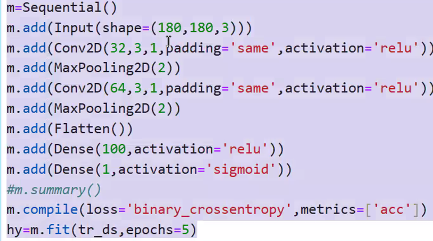

In [68]:
tr_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [62]:
for i in tr_ds:
    print(i[1])

tf.Tensor([1 1 0 0 1 0 0 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 1 0 1 1 0 0 0 1 1 1], shape=(32,), dtype=int32)
tf.Tensor([0 0 1 1 0 0 0 0 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 1 1], shape=(32,), dtype=int32)
tf.Tensor([0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0], shape=(32,), dtype=int32)
tf.Tensor([1 1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 1 0 0 0 0 0 0 1 0], shape=(32,), dtype=int32)
tf.Tensor([1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 0 1], shape=(32,), dtype=int32)
tf.Tensor([1 0 1 1 0 1 1 0 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 1], shape=(32,), dtype=int32)
tf.Tensor([0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 0 0 0 1 0], shape=(32,), dtype=int32)
tf.Tensor([0 0 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 1 1], shape=(32,), dtype=int32)
tf.Tensor([1 0 1 0 1 1 0 1 1 0 0 1 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1], shape=(32,), dtype=int32)
tf.Tensor([1 0 1 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 

In [67]:
m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(tr_ds, epochs=5)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - acc: 0.4950 - loss: 7.8991
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - acc: 0.5000 - loss: 7.9712
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - acc: 0.5000 - loss: 7.9712
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - acc: 0.5000 - loss: 7.9712
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - acc: 0.5000 - loss: 7.9712


In [ ]:
# def __init__(scale, offset=0.0, **kwargs)

In [16]:
from keras.layers import Rescaling, RandomZoom, RandomRotation, RandomFlip # 4가지는 주로 데이터 증강용
# 색상의 스케일링을 진행함(학습시 색상에 의한 오차 범위를 줄임-> 훨씬 안정화된 학습을 진행)
# 변동성은 안정되나 학습이 더뎌질 수 있음
# 즉 안정적 학습을 위해서 사용됨

In [17]:
m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255)) # rescaling(scale=1./127.5, offset=-1) = -1~1사이의 범주로 조정
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(tr_ds, epochs=3)

Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - acc: 0.5235 - loss: 0.8784
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - acc: 0.6230 - loss: 0.6749
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - acc: 0.6860 - loss: 0.6015


2
tf.Tensor([0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 1 1 1 0 1 0 0 0 0 0 1 1 1 0 1 1 0], shape=(32,), dtype=int32)
[0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 1 1 1 0 1 0 0 0 0 0 1 1 1 0 1 1 0]
(180, 180, 3)


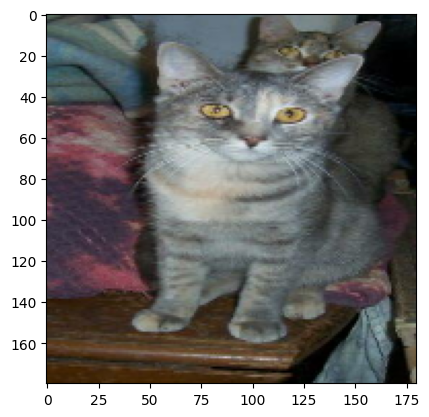

In [31]:
import matplotlib.pyplot as plt
# 데이터 증강 확인
for i in tr_ds:
    print(len(i))
    # print(i) # 마지막에 적힌 것들은 0과 1로 출력하는데 이는 개와 고양이임
    # print(i[0]) # x만 꺼낸 것
    print(i[1]) # 라벨링만 꺼낸것
    print(i[1].numpy()) # 넘파이 형태
    print(i[0].numpy()[0].shape) # 이미지 한장
    plt.imshow(i[0].numpy()[0].astype(np.uint8)) # 데이터가 소수점으로 표시되어 있었으므로 양의 정수로 변환
    break

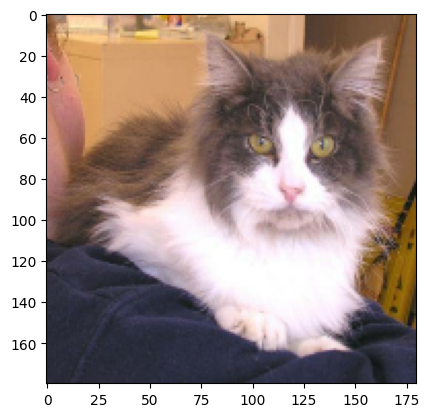

In [ ]:
for imgs, ys in tr_ds: # 한 세트에 32장의 이미지가 들어있으며 출력 때마다 이미지가 셔플됨
    plt.imshow(imgs[0].numpy().astype('uint8'))
    plt.show()
    break

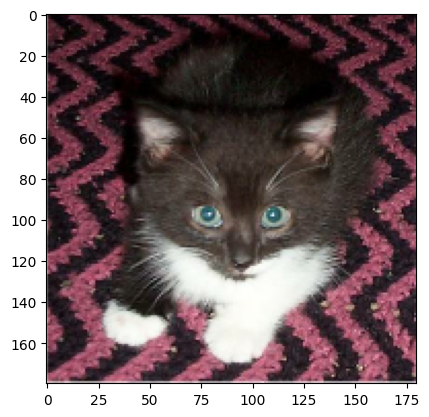

In [45]:
for imgs, ys in tr_ds.take(1): 
    plt.imshow(imgs[0].numpy().astype('uint8'))
    plt.show()
    break

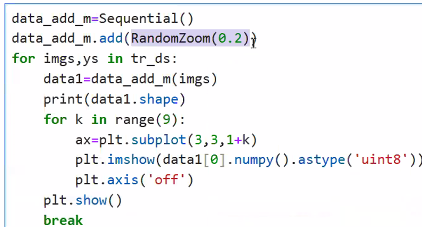

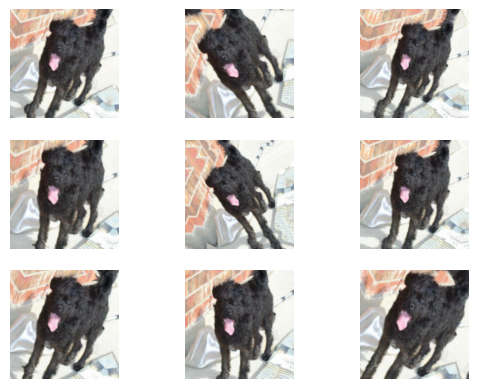

In [113]:
from keras.layers import Rescaling, RandomZoom, RandomRotation, RandomFlip # 4가지는 주로 데이터 증강용
data_add_m=Sequential()
data_add_m.add(RandomZoom(0.2))
data_add_m.add(RandomRotation(0.1))
for imgs, ys in tr_ds:
    for k in range(9):
        data1=data_add_m(imgs)
        ax=plt.subplot(3,3,1+k)
        plt.imshow(data1[0].cpu().numpy().astype('uint8')) # GPU로 돌아가는 거라 cpu를 추가함
        plt.axis('off')
    plt.show()
    break

### 로드한 데이터셋을 이용하여 최적의 모델을 설계후 학습된 모델을 완성하시오
1. 우리가 형성한 데이터셋 함수를 이용하여 데이터를 늘리시오(최대 5000장)(증강기를 쓰라는 얘기가 아님. 즉 데이터셋만 다시 늘려서 사용하라는 것임) 0
2. 학습, 테스트, 검증 데이터셋을 구성하여 사용하시오 0
3. 데이터 스케일링은 계층을 이용하시오 0
4. 데이터 증강 계층을 사용하시오(단 데이터는 변경되면 안됨)
5. 반드시 학습이 완료된 모델은 저장이 완료되어야 함(콜백 함수 활용하시오) 0
6. 선정 내용을 문서로 정리하시오(왜 이 모델을 선정했는가?)

In [2]:
# 작업 준비
import numpy as np
import pandas as pd
# 데이터 분할
from sklearn.model_selection import train_test_split
# 모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, SimpleRNN, \
    LSTM, GRU, BatchNormalization, Flatten, Rescaling, RandomZoom, RandomRotation, RandomFlip
from keras.optimizers import Adam, RMSprop, SGD
from keras.losses import categorical_crossentropy, binary_crossentropy, \
    sparse_categorical_crossentropy, mean_squared_error
# 모델 학습
from keras.callbacks import EarlyStopping, ModelCheckpoint
# 모델 로드
from keras.models import load_model
# 성능 검토
# from keras.metrics import R2Score, RootMeanSquaredError # 다소 어려운 구간임
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error
from keras.utils import to_categorical
import matplotlib.pyplot as plt

# 데이터셋 정리

In [3]:
import os, shutil, pathlib, gdown
old_dir = pathlib.Path('./dogs-vs-cats/train')
new_dir = pathlib.Path('cat-dog-dataset20250820')

In [4]:
def make_subset(sub_n, s_idx, e_idx):
    for i in ['cat', 'dog']:
        dir=new_dir/sub_n/i
        os.makedirs(dir, exist_ok=True)
        f_ns = [f'{i}.{n}.jpg' for n in range(s_idx, e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n,dst=dir/f_n)

In [ ]:
# make_subset('train',0,5000) # 새폴더에 이미지 분류 및 복사
# make_subset('test',5000,10000)
# make_subset('val',10000,2000)
make_subset('train',0,4000) # 새폴더에 이미지 분류 및 복사
make_subset('test',4000,7000)
make_subset('val', 7000,9000) # val데이터셋 따로 생성

In [35]:
from keras.utils import image_dataset_from_directory # 자동으로 데이터셋을 리사이징 작업하고 데이터셋화를 함 -> 조건은 폴더가 정리되어 있어야 함
# train = image_dataset_from_directory(new_dir/'train',batch_size=64, image_size=(180,180))
# test = image_dataset_from_directory(new_dir/'test',batch_size=64, image_size=(180,180))
# val = image_dataset_from_directory(new_dir/'val',batch_size=64, image_size=(180,180))
train = image_dataset_from_directory(new_dir/'train',batch_size=128, image_size=(180,180))
test = image_dataset_from_directory(new_dir/'test',batch_size=128, image_size=(180,180))
val = image_dataset_from_directory(new_dir/'val',batch_size=128, image_size=(180,180))

Found 8000 files belonging to 2 classes.
Found 6000 files belonging to 2 classes.
Found 4000 files belonging to 2 classes.


# 데이터셋 확인

(64, 180, 180, 3)
(64,)
(180, 180, 3)


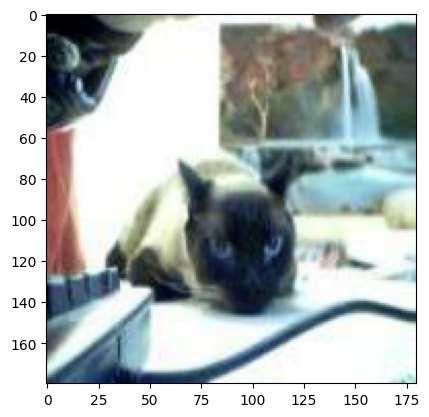

In [8]:
for i in train:
    print(i[0].shape) # 이미지들(배치사이즈만큼)
    print(i[1].shape) # 레이블
    print(i[0][0].shape)
    plt.imshow(i[0][0].numpy().astype('uint8'))
    break

GPU 학습을 할 건데 용량이 남을 거 같아서 배치사이즈 확장함

# 모델 만들기 + 리스케일링

In [119]:
m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1/255))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=50, validation_data=val, callbacks=[es, ch])

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - acc: 0.5049 - loss: 4.8920 - val_acc: 0.5091 - val_loss: 0.6920
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - acc: 0.5844 - loss: 0.6723 - val_acc: 0.6862 - val_loss: 0.6252
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - acc: 0.6865 - loss: 0.5872 - val_acc: 0.6909 - val_loss: 0.5868
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - acc: 0.7408 - loss: 0.5245 - val_acc: 0.6227 - val_loss: 0.6420
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - acc: 0.7793 - loss: 0.4629 - val_acc: 0.6580 - val_loss: 0.7605
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - acc: 0.8143 - loss: 0.4078 - val_acc: 0.7484 - val_loss: 0.5746
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - acc: 0.8472 - loss: 0.3517 - val_acc: 0.7549 - val_loss: 0.5810
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - acc: 0.8785 - loss: 0.2899 - val_acc: 0.7498 - val_loss: 0.5625
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1

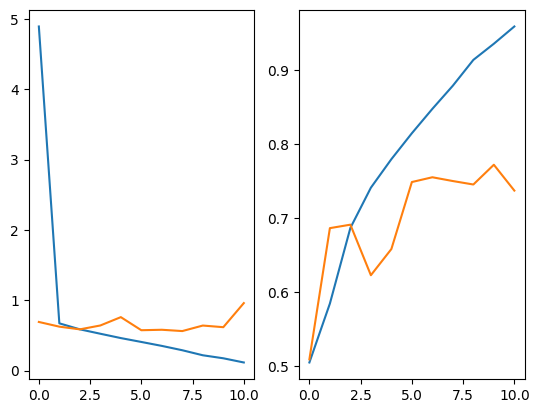

In [123]:
plt.subplot(1,2,1)
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.subplot(1,2,2)
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

# 콜백 함수 설정

In [6]:
es = EarlyStopping(patience=3, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test.keras', save_best_only=True)

# 모델 학습

In [7]:
m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=50, validation_data=val, callbacks=[es, ch])

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - acc: 0.5500 - loss: 0.7127 - val_acc: 0.6233 - val_loss: 0.6619
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - acc: 0.6694 - loss: 0.6069 - val_acc: 0.6709 - val_loss: 0.5899
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - acc: 0.7204 - loss: 0.5484 - val_acc: 0.7171 - val_loss: 0.5412
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - acc: 0.7564 - loss: 0.5006 - val_acc: 0.7660 - val_loss: 0.4904
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.7832 - loss: 0.4586 - val_acc: 0.7522 - val_loss: 0.5125
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - acc: 0.8159 - loss: 0.3999 - val_acc: 0.8016 - val_loss: 0.4236
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - acc: 0.8391 - loss: 0.3593 - val_acc: 0.7893 - val_loss: 0.4515
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - acc: 0.8697 - loss: 0.2958 - val_acc: 0.8142 - val_loss: 0.4515
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 

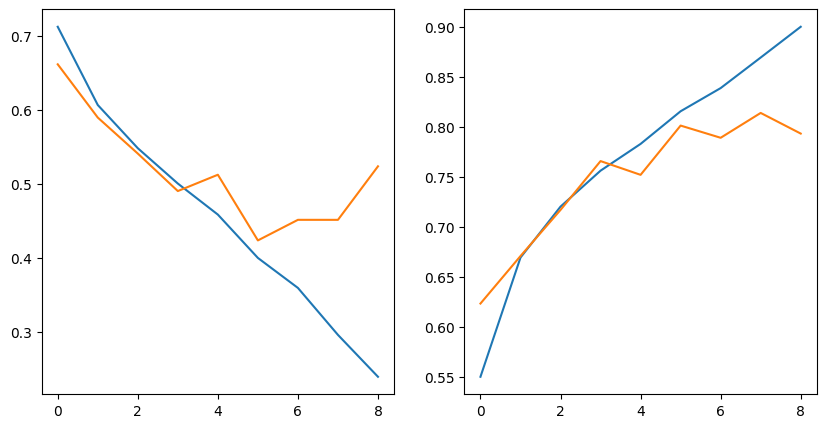

In [10]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.subplot(1,2,2)
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [11]:
es = EarlyStopping(patience=3, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_1.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=50, validation_data=val, callbacks=[es, ch])

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - acc: 0.5210 - loss: 0.7218 - val_acc: 0.6167 - val_loss: 0.6552
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - acc: 0.5928 - loss: 0.6673 - val_acc: 0.6331 - val_loss: 0.6349
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - acc: 0.6601 - loss: 0.6155 - val_acc: 0.7102 - val_loss: 0.5657
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.7113 - loss: 0.5566 - val_acc: 0.6929 - val_loss: 0.5762
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - acc: 0.7468 - loss: 0.5141 - val_acc: 0.7493 - val_loss: 0.5134
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - acc: 0.7702 - loss: 0.4753 - val_acc: 0.7656 - val_loss: 0.4782
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - acc: 0.7888 - loss: 0.4399 - val_acc: 0.7791 - val_loss: 0.4707
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - acc: 0.8268 - loss: 0.3854 - val_acc: 0.7902 - val_loss: 0.4575
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 

In [13]:
es = EarlyStopping(patience=3, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_1.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=50, validation_data=val, callbacks=[es, ch])

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.5229 - loss: 0.7185 - val_acc: 0.5556 - val_loss: 0.6872
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.6060 - loss: 0.6588 - val_acc: 0.6389 - val_loss: 0.6370
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.6576 - loss: 0.6178 - val_acc: 0.7140 - val_loss: 0.5475
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - acc: 0.7256 - loss: 0.5452 - val_acc: 0.7536 - val_loss: 0.5091
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - acc: 0.7640 - loss: 0.4902 - val_acc: 0.7724 - val_loss: 0.4680
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - acc: 0.7885 - loss: 0.4499 - val_acc: 0.7873 - val_loss: 0.4480
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - acc: 0.8160 - loss: 0.4113 - val_acc: 0.8033 - val_loss: 0.4286
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - acc: 0.8334 - loss: 0.3738 - val_acc: 0.8107 - val_loss: 0.4223
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 

In [16]:
es = EarlyStopping(patience=3, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_2.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adamw', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=50, validation_data=val, callbacks=[es, ch])

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 138ms/step - acc: 0.6629 - loss: 0.7871 - val_acc: 0.5556 - val_loss: 1.4714
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - acc: 0.7349 - loss: 0.5274 - val_acc: 0.5556 - val_loss: 1.6316
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step - acc: 0.7737 - loss: 0.4665 - val_acc: 0.5731 - val_loss: 1.4134
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - acc: 0.8213 - loss: 0.3971 - val_acc: 0.6520 - val_loss: 1.0982
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - acc: 0.8541 - loss: 0.3294 - val_acc: 0.7556 - val_loss: 0.5319
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - acc: 0.8857 - loss: 0.2693 - val_acc: 0.8053 - val_loss: 0.4641
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step - acc: 0.9046 - loss: 0.2249 - val_acc: 0.7736 - val_loss: 0.6129
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - acc: 0.9378 - loss: 0.1528 - val_acc: 0.7427 - val_loss: 0.7120
Epoch 9/50
157/157 ━━━━━━━━━━━━━

In [17]:
es = EarlyStopping(patience=3, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_2.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adamw', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=50, validation_data=val, callbacks=[es, ch])

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 208ms/step - acc: 0.5545 - loss: 0.9721 - val_acc: 0.5556 - val_loss: 0.7426
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 211ms/step - acc: 0.6230 - loss: 0.6547 - val_acc: 0.5560 - val_loss: 0.7693
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 210ms/step - acc: 0.6709 - loss: 0.6036 - val_acc: 0.5618 - val_loss: 1.0279
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 210ms/step - acc: 0.7341 - loss: 0.5302 - val_acc: 0.6778 - val_loss: 0.6041
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 213ms/step - acc: 0.7646 - loss: 0.4905 - val_acc: 0.6767 - val_loss: 0.5891
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 209ms/step - acc: 0.8056 - loss: 0.4251 - val_acc: 0.7609 - val_loss: 0.5739
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 210ms/step - acc: 0.8341 - loss: 0.3802 - val_acc: 0.7533 - val_loss: 0.4917
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 212ms/step - acc: 0.8528 - loss: 0.3384 - val_acc: 0.7609 - val_loss: 0.4680
Epoch 9/50
157/157 ━━━━━━━━━━━━━

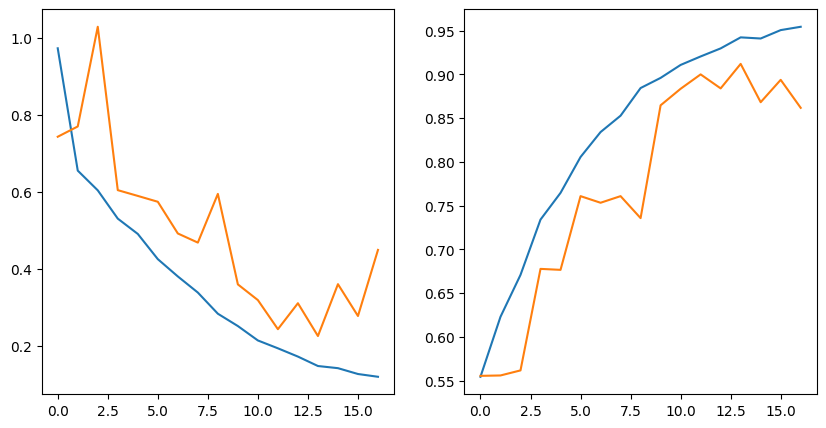

In [18]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.subplot(1,2,2)
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [19]:
m.evaluate(test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - acc: 0.9108 - loss: 0.2196


[0.2196158468723297, 0.9107999801635742]

In [29]:
es = EarlyStopping(patience=5, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_3.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(RandomRotation(0.1))

m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))

m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adamw', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=50, validation_data=val, callbacks=[es, ch])

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 325ms/step - acc: 0.5534 - loss: 0.9951 - val_acc: 0.4871 - val_loss: 0.7262
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 346ms/step - acc: 0.6173 - loss: 0.6625 - val_acc: 0.5556 - val_loss: 1.0102
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 369ms/step - acc: 0.6675 - loss: 0.6066 - val_acc: 0.6060 - val_loss: 0.6631
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 367ms/step - acc: 0.7042 - loss: 0.5652 - val_acc: 0.6149 - val_loss: 0.6946
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 57s 364ms/step - acc: 0.7299 - loss: 0.5364 - val_acc: 0.7109 - val_loss: 0.5907
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 356ms/step - acc: 0.7654 - loss: 0.4857 - val_acc: 0.5187 - val_loss: 0.7542
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - acc: 0.7816 - loss: 0.4656 - val_acc: 0.7896 - val_loss: 0.4426
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - acc: 0.7989 - loss: 0.4311 - val_acc: 0.6838 - val_loss: 0.6186
Epoch 9/50
157/157 ━━━━━━━━━━━━━

In [30]:
es = EarlyStopping(patience=5, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_4.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(RandomZoom(0.2))
m.add(RandomRotation(0.1))

m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))

m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adamw', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=100, validation_data=val, callbacks=[es, ch])

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 449ms/step - acc: 0.5459 - loss: 0.8322 - val_acc: 0.5556 - val_loss: 0.7881
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 72s 461ms/step - acc: 0.6087 - loss: 0.6697 - val_acc: 0.5051 - val_loss: 0.7521
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 73s 465ms/step - acc: 0.6699 - loss: 0.6024 - val_acc: 0.5904 - val_loss: 0.7272
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 75s 474ms/step - acc: 0.6992 - loss: 0.5747 - val_acc: 0.6753 - val_loss: 0.6094
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 485ms/step - acc: 0.7265 - loss: 0.5417 - val_acc: 0.6769 - val_loss: 0.6796
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 482ms/step - acc: 0.7467 - loss: 0.5181 - val_acc: 0.4478 - val_loss: 1.2513
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 88s 557ms/step - acc: 0.7584 - loss: 0.4951 - val_acc: 0.7480 - val_loss: 0.5434
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - acc: 0.7792 - loss: 0.4593 - val_acc: 0.6411 - val_loss: 0.6103
Epoch 9/100
157/157 ━━━━━━

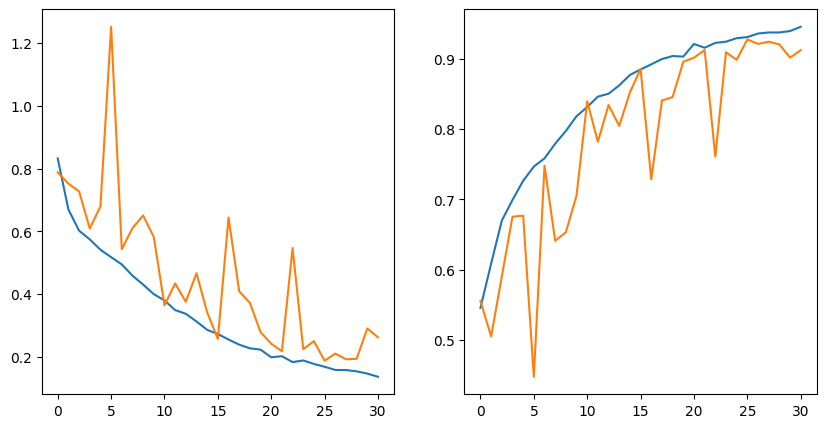

In [32]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.subplot(1,2,2)
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [31]:
m.evaluate(test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - acc: 0.9279 - loss: 0.1827


[0.1827467978000641, 0.9279000163078308]

## 데이터셋 변경

In [2]:
torch.cuda.is_available()

True

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
import torch

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.backend.backend()}") # 이 부분이 'torch'로 나와야 합니다.
print(f"PyTorch version: {torch.__version__}")

Keras version: 3.11.2
Keras backend: torch
PyTorch version: 2.7.1+cu118


In [2]:
# 작업 준비
import numpy as np
import pandas as pd
# 데이터 분할
from sklearn.model_selection import train_test_split
# 모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, SimpleRNN, \
    LSTM, GRU, BatchNormalization, Flatten, Rescaling, RandomZoom, RandomRotation, RandomFlip
from keras.optimizers import Adam, RMSprop, SGD
from keras.losses import categorical_crossentropy, binary_crossentropy, \
    sparse_categorical_crossentropy, mean_squared_error
# 모델 학습
from keras.callbacks import EarlyStopping, ModelCheckpoint
# 모델 로드
from keras.models import load_model
# 성능 검토
# from keras.metrics import R2Score, RootMeanSquaredError # 다소 어려운 구간임
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error
from keras.utils import to_categorical
import matplotlib.pyplot as plt

In [3]:
import os, shutil, pathlib, gdown
old_dir = pathlib.Path('./dogs-vs-cats/train')
new_dir = pathlib.Path('cat-dog-dataset20250820')

In [ ]:
def make_subset(sub_n, s_idx, e_idx):
    for i in ['cat', 'dog']:
        dir=new_dir/sub_n/i
        os.makedirs(dir, exist_ok=True)
        f_ns = [f'{i}.{n}.jpg' for n in range(s_idx, e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n,dst=dir/f_n)

In [ ]:
# make_subset('train',0,5000) # 새폴더에 이미지 분류 및 복사
# make_subset('test',5000,10000)
# make_subset('val',10000,2000)
make_subset('train',0,4000) # 새폴더에 이미지 분류 및 복사
make_subset('test',4000,7000)
make_subset('val', 7000,9000) # val데이터셋 따로 생성

In [4]:
from keras.utils import image_dataset_from_directory # 자동으로 데이터셋을 리사이징 작업하고 데이터셋화를 함 -> 조건은 폴더가 정리되어 있어야 함
# train = image_dataset_from_directory(new_dir/'train',batch_size=64, image_size=(180,180))
# test = image_dataset_from_directory(new_dir/'test',batch_size=64, image_size=(180,180))
# val = image_dataset_from_directory(new_dir/'val',batch_size=64, image_size=(180,180))
train = image_dataset_from_directory(new_dir/'train',batch_size=128, image_size=(180,180))
test = image_dataset_from_directory(new_dir/'test',batch_size=128, image_size=(180,180))
val = image_dataset_from_directory(new_dir/'val',batch_size=128, image_size=(180,180))

c:\Users\devchoi\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\devchoi\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\devchoi\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violat

Found 8000 files belonging to 2 classes.
Found 6000 files belonging to 2 classes.
Found 4000 files belonging to 2 classes.


In [5]:
es = EarlyStopping(patience=5, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_5.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
# m.add(RandomZoom(0.2))
# m.add(RandomRotation(0.1))

m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))

m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adamw', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=100, validation_data=val, callbacks=[es, ch])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 407ms/step - acc: 0.5571 - loss: 1.4227 - val_acc: 0.5000 - val_loss: 0.7224
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 409ms/step - acc: 0.6010 - loss: 0.6863 - val_acc: 0.4997 - val_loss: 0.7115
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 415ms/step - acc: 0.6436 - loss: 0.6506 - val_acc: 0.5005 - val_loss: 0.7079
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 404ms/step - acc: 0.6722 - loss: 0.6150 - val_acc: 0.5015 - val_loss: 0.8177
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 414ms/step - acc: 0.7045 - loss: 0.5768 - val_acc: 0.5120 - val_loss: 0.6975
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 401ms/step - acc: 0.7386 - loss: 0.5284 - val_acc: 0.5023 - val_loss: 0.8824
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 401ms/step - acc: 0.7581 - loss: 0.4947 - val_acc: 0.5155 - val_loss: 0.7985
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 412ms/step - acc: 0.7835 - loss: 0.4645 - val_acc: 0.6187 - val_loss: 0.6692
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 2

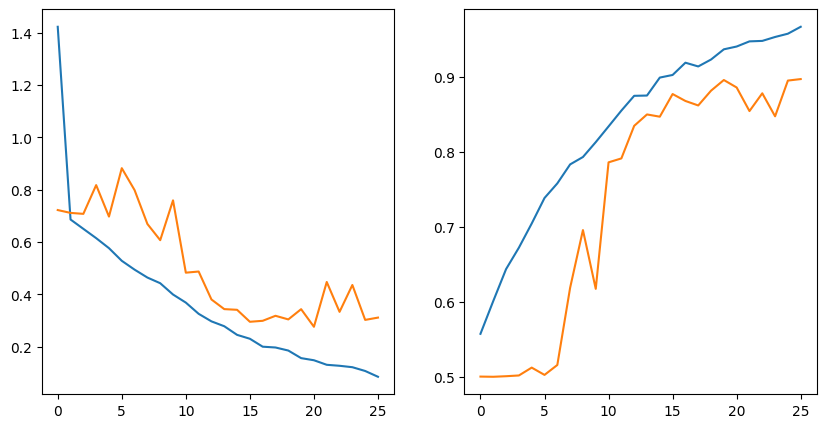

In [6]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.subplot(1,2,2)
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [7]:
m.evaluate(test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - acc: 0.8938 - loss: 0.2723


[0.2723430097103119, 0.893833339214325]

추세를 봤을 땐 애매한 상황인 것 같음...더 해봐야할지 아니면 그냥 둘지 일단 지켜보는 걸로

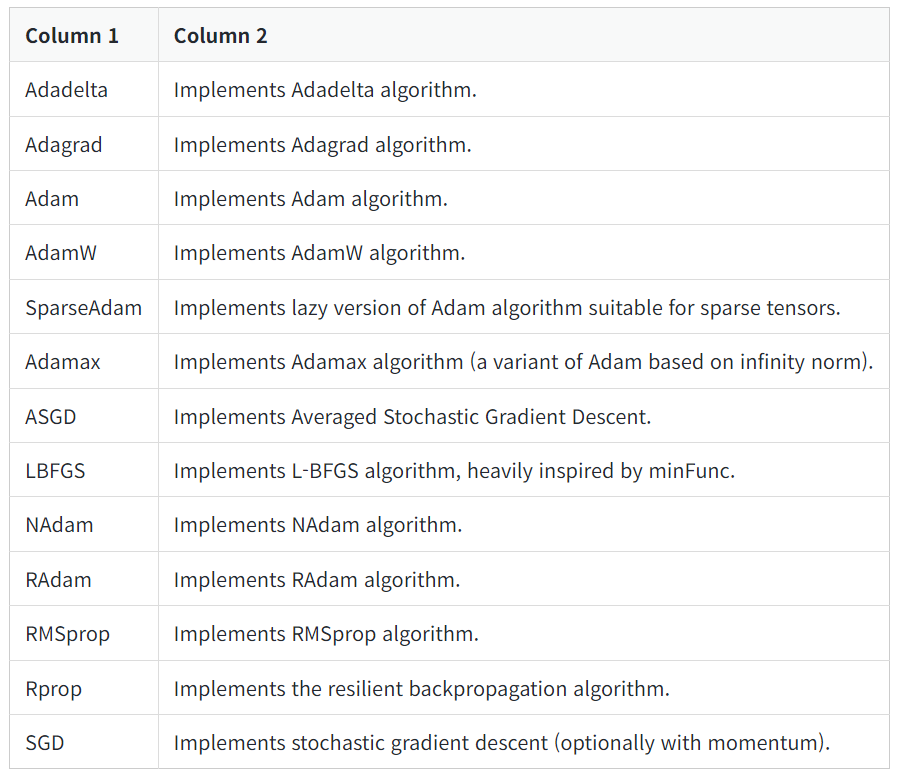

- Lion (EvoLved Sign Momentum) 케라스에 있음
- AdaBelief
- SGD with Momentum
어떤 최적화 함수가 좋을지 몰라서 참고용으로 가져옴

In [ ]:
class CustomAdaBelief(keras.optimizers.Optimizer):
    def __init__(
        self,
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8,
        weight_decay=1e-2, # AdamW 스타일의 가중치 감쇠
        name="CustomAdaBelief",
        **kwargs
    ):
        super().__init__(name=name, **kwargs)
        self.learning_rate = learning_rate
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon
        self.weight_decay = weight_decay

    def build(self, variables):
        # 모델의 각 학습 가능한 변수(가중치)에 대해
        # 상태 변수 m과 s를 생성합니다.
        for var in variables:
            self.add_variable(
                name="m",
                shape=var.shape,
                initializer="zeros",
                trainable=False,
                assign_to=var
            )
            self.add_variable(
                name="s",
                shape=var.shape,
                initializer="zeros",
                trainable=False,
                assign_to=var
            )

    def update_step(self, gradient, variable):
        # 현재 스텝(iteration)을 가져옵니다. 타입 변환이 필요합니다.
        step = keras.ops.cast(self.iterations + 1, dtype=torch.float32)

        # 저장된 상태 변수 m과 s를 가져옵니다.
        m = self.get_variable("m", variable)
        s = self.get_variable("s", variable)

        # --- AdaBelief 핵심 로직 ---
        # 1. 첫 번째 모멘텀(m) 업데이트 (Adam과 동일)
        m_t = self.beta_1 * m + (1 - self.beta_1) * gradient
        
        # 2. 두 번째 모멘텀(s) 업데이트 (AdaBelief의 핵심)
        # (gradient - m_t)^2 를 사용합니다.
        s_t = self.beta_2 * s + (1 - self.beta_2) * keras.ops.square(gradient - m_t) + self.epsilon

        # 상태 변수 m과 s를 새로운 값으로 업데이트
        m.assign(m_t)
        s.assign(s_t)

        # 3. Bias-correction (편향 보정)
        m_hat = m_t / (1 - keras.ops.power(self.beta_1, step))
        s_hat = s_t / (1 - keras.ops.power(self.beta_2, step))

        # 4. 최종 업데이트 값 계산
        update = m_hat / (keras.ops.sqrt(s_hat) + self.epsilon)

        # --- 가중치 업데이트 ---
        # 5. 가중치 감쇠 (Weight Decay) 적용
        variable_update = variable - self.learning_rate * self.weight_decay * variable
        
        # 6. 최종 가중치 업데이트
        variable_update = variable_update - self.learning_rate * update
        
        variable.assign(variable_update)

    def get_config(self):
        config = super().get_config()
        config.update({
            "learning_rate": self.learning_rate,
            "beta_1": self.beta_1,
            "beta_2": self.beta_2,
            "epsilon": self.epsilon,
            "weight_decay": self.weight_decay,
        })
        return config
    
CustomAdaBelief(learning_rate=0.001,weight_decay=0.01)

In [8]:
es = EarlyStopping(patience=7, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_5.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
# m.add(RandomZoom(0.2))
m.add(RandomRotation(0.1))

m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))

m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adamw', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=100, validation_data=val, callbacks=[es, ch])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 768ms/step - acc: 0.5379 - loss: 1.3803 - val_acc: 0.5000 - val_loss: 0.7399
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 750ms/step - acc: 0.5753 - loss: 0.6903 - val_acc: 0.5000 - val_loss: 0.8051
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 819ms/step - acc: 0.6308 - loss: 0.6421 - val_acc: 0.5000 - val_loss: 0.8533
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 826ms/step - acc: 0.6545 - loss: 0.6274 - val_acc: 0.5000 - val_loss: 1.0212
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 50s 796ms/step - acc: 0.6927 - loss: 0.5793 - val_acc: 0.5222 - val_loss: 0.7171
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 830ms/step - acc: 0.7121 - loss: 0.5562 - val_acc: 0.5000 - val_loss: 1.2312
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 808ms/step - acc: 0.7320 - loss: 0.5334 - val_acc: 0.5023 - val_loss: 0.9413
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 803ms/step - acc: 0.7514 - loss: 0.5078 - val_acc: 0.6787 - val_loss: 0.5915
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5

In [9]:
m.evaluate(test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - acc: 0.9185 - loss: 0.2087


[0.20865140855312347, 0.9185000061988831]

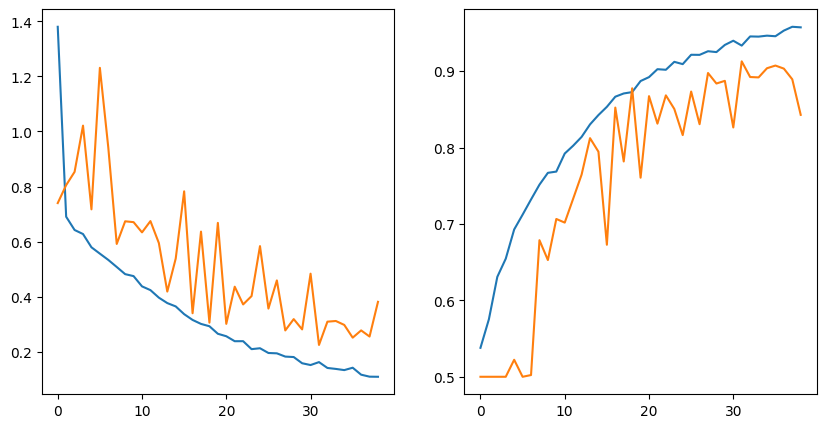

In [10]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.subplot(1,2,2)
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [ ]:
es = EarlyStopping(patience=7, restore_best_weights=True)
ch = ModelCheckpoint('20250820_level_test_6.keras', save_best_only=True)

m=Sequential()
m.add(Input(shape=(180,180,3)))
m.add(Rescaling(scale=1./255))
m.add(RandomZoom(0.2))
# m.add(RandomRotation(0.1))

m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(Conv2D(32,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(Conv2D(64,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(Conv2D(128,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(Conv2D(256,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))
m.add(Dropout(0.3))

m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(Conv2D(512,3,1, padding='same', activation='relu'))
m.add(BatchNormalization())
m.add(MaxPooling2D(2))

m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(Dense(1, activation='sigmoid'))
# m.summary()
m.compile(optimizer='adamw', loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(train, epochs=100, validation_data=val, callbacks=[es, ch])

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 676ms/step - acc: 0.5409 - loss: 1.1279 - val_acc: 0.5073 - val_loss: 0.6987
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 678ms/step - acc: 0.6100 - loss: 0.6705 - val_acc: 0.5013 - val_loss: 0.7113
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 691ms/step - acc: 0.6578 - loss: 0.6299 - val_acc: 0.5013 - val_loss: 0.7139
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 690ms/step - acc: 0.6865 - loss: 0.5933 - val_acc: 0.5000 - val_loss: 0.8581
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 732ms/step - acc: 0.7186 - loss: 0.5501 - val_acc: 0.5008 - val_loss: 0.9916
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 728ms/step - acc: 0.7281 - loss: 0.5315 - val_acc: 0.5035 - val_loss: 0.7831
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 747ms/step - acc: 0.7495 - loss: 0.5078 - val_acc: 0.5770 - val_loss: 0.7264
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 743ms/step - acc: 0.7630 - loss: 0.4848 - val_acc: 0.7090 - val_loss: 0.5924
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:
# 4. 데이터 증강 계층을 사용하시오(단 데이터는 변경되면 안됨)
